In [15]:
import warnings
warnings.filterwarnings('ignore')

import random
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PALETTE = {
    'actual':  '#1f2933',   # near-black
    'arima':   '#3b82f6',   # blue
    'hybrid':  '#e11d48',   # rose
    'accent':  '#0f766e',   # teal
    'warn':    '#d97706',   # amber
    'split':   '#15803d',   # green
}
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.edgecolor':   '#cbd5e1',
    'axes.grid':        True,
    'grid.color':       '#e2e8f0',
    'grid.linestyle':   ':',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'legend.frameon':   False,
    'font.size':        10,
})

In [16]:
TICKER = 'GOOG'
print(f'Downloading {TICKER} historical data...')

alphabet_ticker = yf.Ticker(TICKER)
raw_history = alphabet_ticker.history(period='10y')
close_prices = raw_history['Close'].dropna()

total_obs  = len(close_prices)
train_size = int(total_obs * 0.8)
test_size  = total_obs - train_size

train_prices = close_prices.iloc[:train_size]
test_prices  = close_prices.iloc[train_size:]

print('\n--- Data Setup Complete ---')
print(f'Total records:      {total_obs} trading days')
print(f'Training (80%):     {train_size} trading days')
print(f'Testing  (20%):     {test_size} trading days')
print(f'Date range:         {close_prices.index.min().date()}  ->  {close_prices.index.max().date()}')


--- Data Setup Complete ---
Total records:      2513 trading days
Training (80%):     2010 trading days
Testing  (20%):     503 trading days
Date range:         2016-07-05  ->  2026-07-02


STATIONARITY ANALYSIS
Raw series (d=0)  ADF p-value: 0.9855
First difference (d=1) ADF p-value: 1.8262e-28
Conclusion: the first difference is stationary -> use d = 1.



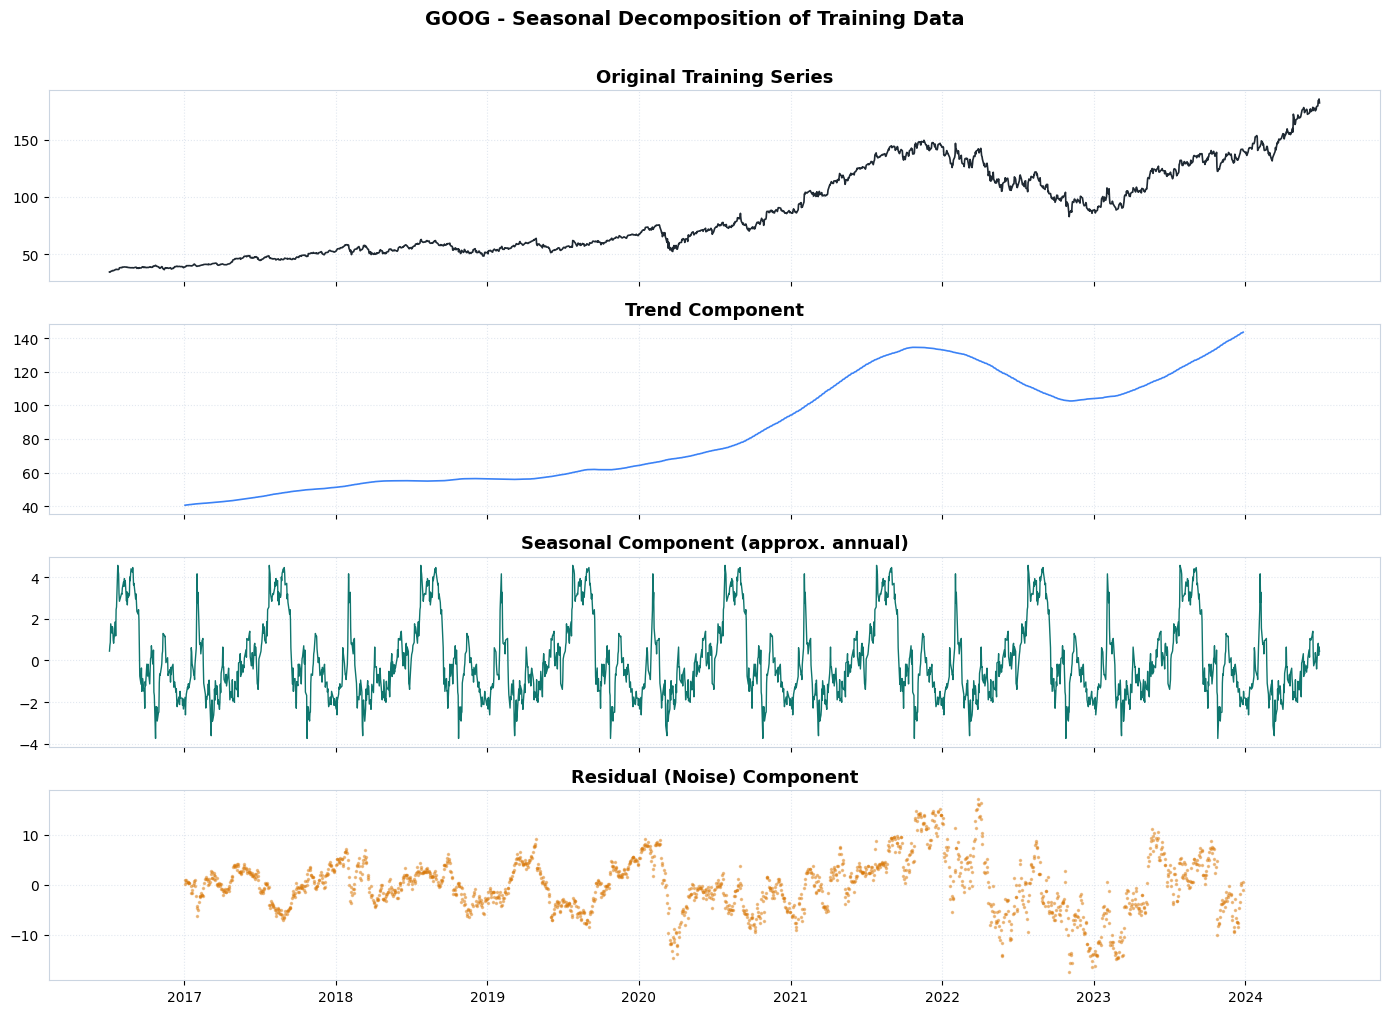

In [17]:
print('STATIONARITY ANALYSIS')
pval_level = adfuller(train_prices)[1]
print(f'Raw series (d=0)  ADF p-value: {pval_level:.4f}')

diff_train = train_prices.diff(1).dropna()
pval_diff = adfuller(diff_train)[1]
print(f'First difference (d=1) ADF p-value: {pval_diff:.4e}')
print('Conclusion: the first difference is stationary -> use d = 1.\n')

decomposition = seasonal_decompose(train_prices, period=252, model='additive')

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(train_prices, color=PALETTE['actual'], lw=1.2)
axes[0].set_title('Original Training Series')
axes[1].plot(decomposition.trend, color=PALETTE['arima'], lw=1.2)
axes[1].set_title('Trend Component')
axes[2].plot(decomposition.seasonal, color=PALETTE['accent'], lw=1.0)
axes[2].set_title('Seasonal Component (approx. annual)')
axes[3].plot(decomposition.resid, '.', color=PALETTE['warn'], alpha=0.4, ms=3)
axes[3].set_title('Residual (Noise) Component')
fig.suptitle(f'{TICKER} - Seasonal Decomposition of Training Data', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

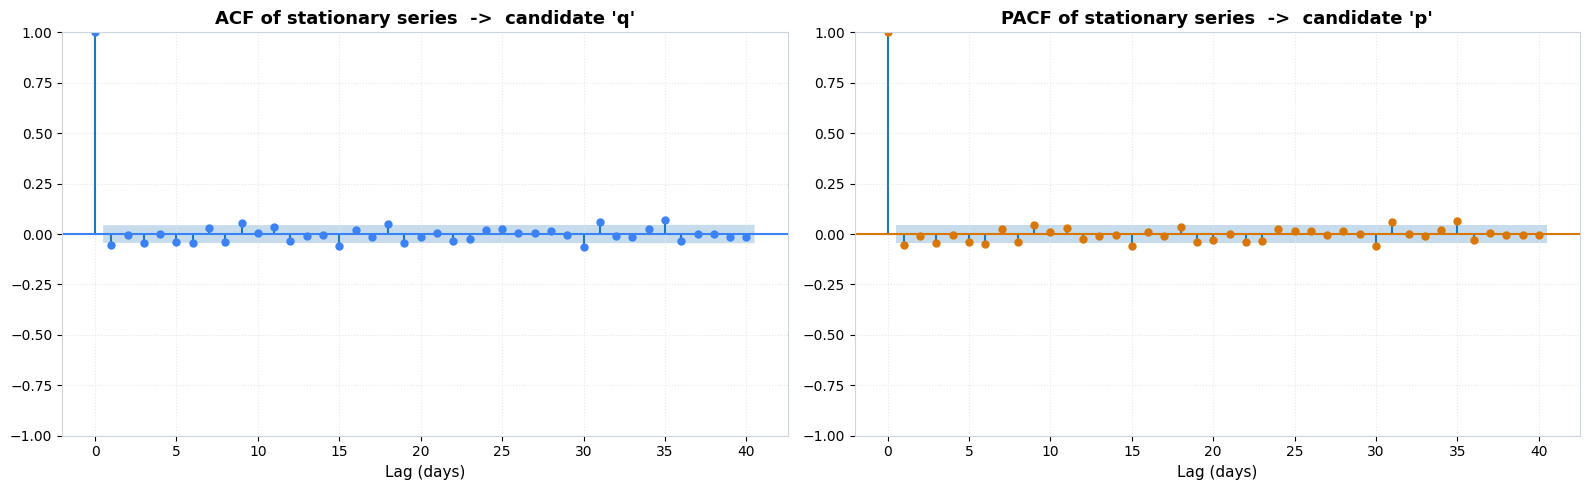

In [18]:
fig, (ax_acf, ax_pacf) = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(diff_train, lags=40, ax=ax_acf, color=PALETTE['arima'])
ax_acf.set_title("ACF of stationary series  ->  candidate 'q'")
ax_acf.set_xlabel('Lag (days)')

plot_pacf(diff_train, lags=40, ax=ax_pacf, color=PALETTE['warn'], method='ywm')
ax_pacf.set_title("PACF of stationary series  ->  candidate 'p'")
ax_pacf.set_xlabel('Lag (days)')

plt.tight_layout()
plt.show()

In [19]:
import itertools

d = 1
best_aic = np.inf
best_order = (1, 1, 1)
search_log = []

for p, q in itertools.product(range(4), range(4)):
    try:
        aic = ARIMA(train_prices, order=(p, d, q)).fit().aic
        search_log.append(((p, d, q), aic))
        if aic < best_aic:
            best_aic, best_order = aic, (p, d, q)
    except Exception:
        continue

arima_order = (1,1,1)
print('Top 5 ARIMA orders by AIC:')
for order, aic in sorted(search_log, key=lambda x: x[1])[:5]:
    marker = '  <-- selected' if order == arima_order else ''
    print(f'  ARIMA{order}:  AIC = {aic:,.1f}{marker}')
print(f'\nSelected order: ARIMA{arima_order}')

Top 5 ARIMA orders by AIC:
  ARIMA(3, 1, 3):  AIC = 7,894.2
  ARIMA(1, 1, 1):  AIC = 7,906.7  <-- selected
  ARIMA(0, 1, 3):  AIC = 7,907.9
  ARIMA(0, 1, 1):  AIC = 7,908.2
  ARIMA(1, 1, 0):  AIC = 7,908.3

Selected order: ARIMA(1, 1, 1)


In [20]:
print(f'Running walk-forward ARIMA{arima_order} over {test_size} test days...')

train_values = train_prices.values.astype(float)
test_values  = test_prices.values.astype(float)

walk_model = ARIMA(train_values, order=arima_order).fit()
arima_forecasts = []

for t in range(test_size):
    if t % 100 == 0 or t == test_size - 1:
        print(f'  progress: day {t}/{test_size}')

    arima_forecasts.append(float(walk_model.forecast(steps=1)[0]))

    walk_model = walk_model.append([test_values[t]], refit=False)

arima_forecasts = np.array(arima_forecasts)

insample_model     = ARIMA(train_prices, order=arima_order).fit()
insample_residuals = insample_model.resid.iloc[1:]
oos_residuals      = test_values - arima_forecasts

print('\nWalk-forward complete.')

Running walk-forward ARIMA(1, 1, 1) over 503 test days...
  progress: day 0/503
  progress: day 100/503
  progress: day 200/503
  progress: day 300/503
  progress: day 400/503
  progress: day 500/503
  progress: day 502/503

Walk-forward complete.


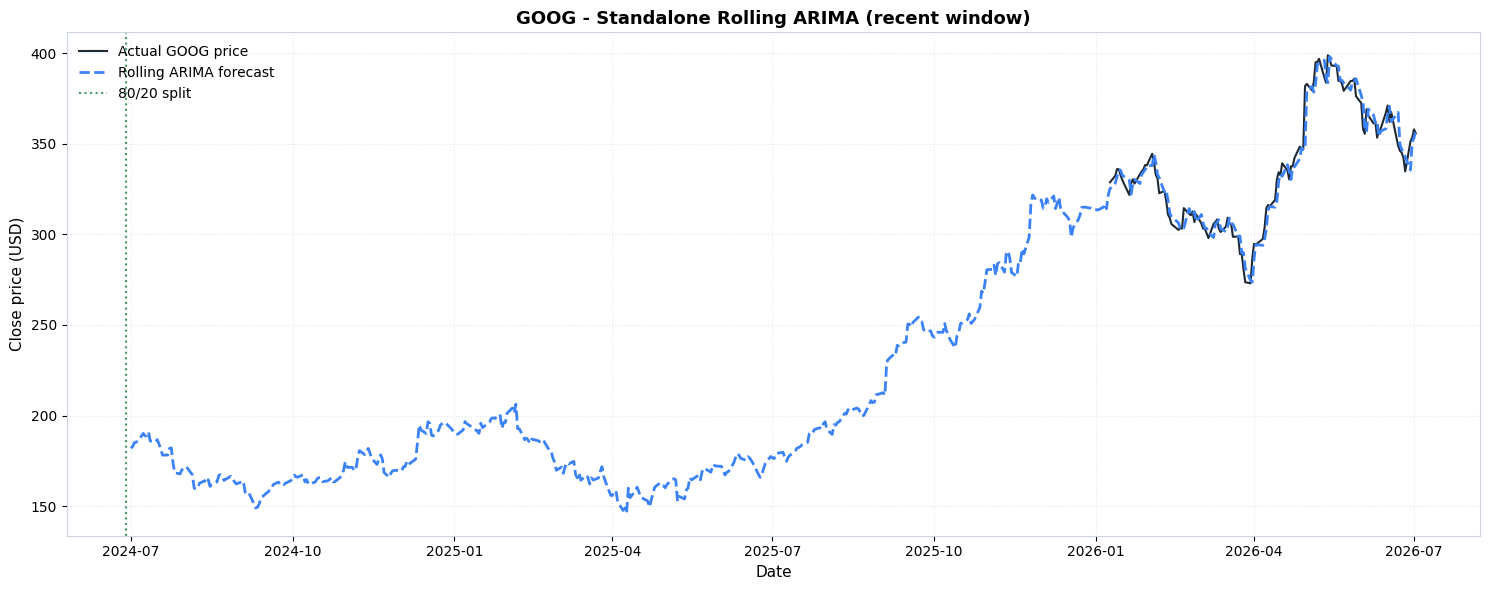

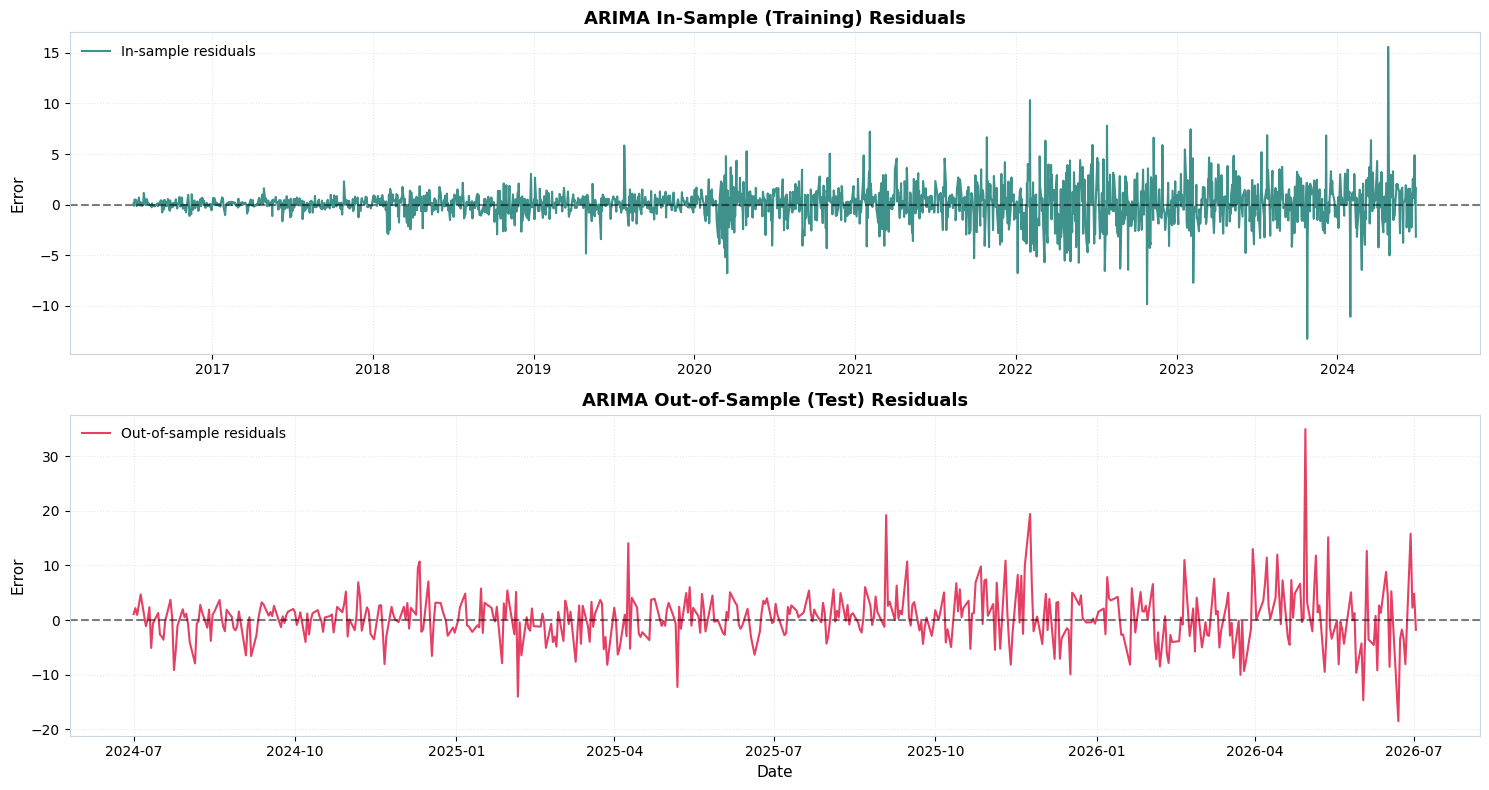

In [21]:
plt.figure(figsize=(15, 6))
plt.plot(close_prices.index[-120:], close_prices.iloc[-120:], color=PALETTE['actual'], lw=1.5, label=f'Actual {TICKER} price')
plt.plot(test_prices.index, arima_forecasts, color=PALETTE['arima'], lw=2, ls='--', label='Rolling ARIMA forecast')
plt.axvline(train_prices.index[-1], color=PALETTE['split'], ls=':', alpha=0.8, label='80/20 split')
plt.title(f'{TICKER} - Standalone Rolling ARIMA (recent window)')
plt.xlabel('Date'); plt.ylabel('Close price (USD)')
plt.legend(loc='upper left')
plt.tight_layout(); plt.show()

fig, (ax_in, ax_out) = plt.subplots(2, 1, figsize=(15, 8))
ax_in.plot(insample_residuals.index, insample_residuals.values, color=PALETTE['accent'], alpha=0.8, label='In-sample residuals')
ax_in.axhline(0, color='black', ls='--', alpha=0.5)
ax_in.set_title('ARIMA In-Sample (Training) Residuals'); ax_in.set_ylabel('Error'); ax_in.legend(loc='upper left')

ax_out.plot(test_prices.index, oos_residuals, color=PALETTE['hybrid'], alpha=0.85, label='Out-of-sample residuals')
ax_out.axhline(0, color='black', ls='--', alpha=0.5)
ax_out.set_title('ARIMA Out-of-Sample (Test) Residuals'); ax_out.set_xlabel('Date'); ax_out.set_ylabel('Error'); ax_out.legend(loc='upper left')
plt.tight_layout(); plt.show()

In [22]:
residual_scaler   = MinMaxScaler(feature_range=(-1, 1))
scaled_train_resid = residual_scaler.fit_transform(insample_residuals.values.reshape(-1, 1))

full_residuals    = np.concatenate([insample_residuals.values, oos_residuals])
scaled_full_resid = residual_scaler.transform(full_residuals.reshape(-1, 1))

WINDOW_SIZE = 10
feature_seqs, target_seqs = [], []
for i in range(len(scaled_train_resid) - WINDOW_SIZE):
    feature_seqs.append(scaled_train_resid[i:i + WINDOW_SIZE, 0])
    target_seqs.append(scaled_train_resid[i + WINDOW_SIZE, 0])

feature_seqs = np.array(feature_seqs).reshape(-1, WINDOW_SIZE, 1)
target_seqs  = np.array(target_seqs)

print(f'LSTM feature tensor: {feature_seqs.shape}')
print(f'LSTM target vector:  {target_seqs.shape}')

LSTM feature tensor: (1999, 10, 1)
LSTM target vector:  (1999,)


In [23]:
residual_lstm = Sequential([
    Input(shape=(WINDOW_SIZE, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1),
])
residual_lstm.compile(optimizer=Adam(learning_rate=1e-3), loss='mean_squared_error')
residual_lstm.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

print('\nTraining LSTM on ARIMA residuals...')
train_history = residual_lstm.fit(
    feature_seqs, target_seqs,
    epochs=60, batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1,
)
print('LSTM training complete.')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 10, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM on ARIMA residuals...
Epoch 1/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0131 - val_loss: 0.0322
Epoch 2/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0125 - val_loss: 0.0321
Epoch 3/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0125 - val_loss: 0.0321
Epoch 4/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0125 - val_loss: 0.0321
Epoch 5/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0126 - val_loss: 0.0321
Epoch 6/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0125 - val_loss: 0.0321
Epoch 7/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0125 - val_loss: 0.0321
Epoch 8/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0125 - val_loss: 0.0321
Epoch 9/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0125 - val_loss: 0.0322
Epoch 10/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0125 - val_loss: 0.0321
Epoch 11/60
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0125 - val_loss: 0.0321
Epoch 12/60
57/57 ━━━━━━━━

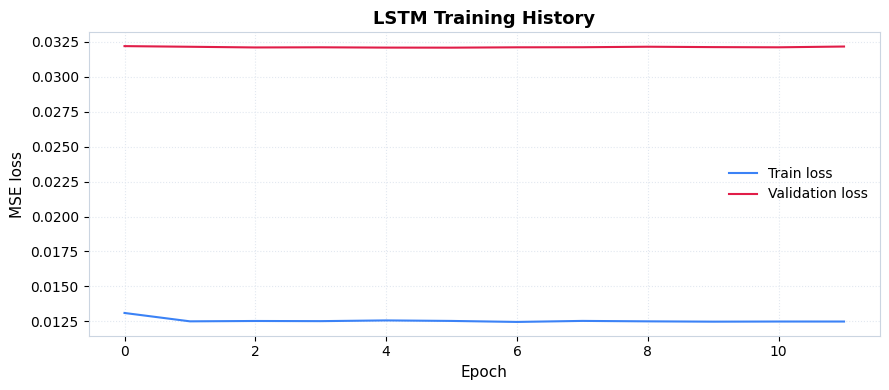

In [24]:
plt.figure(figsize=(9, 4))
plt.plot(train_history.history['loss'], color=PALETTE['arima'], label='Train loss')
plt.plot(train_history.history['val_loss'], color=PALETTE['hybrid'], label='Validation loss')
plt.title('LSTM Training History'); plt.xlabel('Epoch'); plt.ylabel('MSE loss')
plt.legend(); plt.tight_layout(); plt.show()

In [25]:
start_idx = len(scaled_train_resid)
test_frames = np.array([
    scaled_full_resid[start_idx + t - WINDOW_SIZE:start_idx + t, 0]
    for t in range(test_size)
]).reshape(-1, WINDOW_SIZE, 1)

scaled_resid_preds  = residual_lstm.predict(test_frames, verbose=0).flatten()
lstm_resid_forecasts = residual_scaler.inverse_transform(
    scaled_resid_preds.reshape(-1, 1)
).flatten()

print(f'Predicted {len(lstm_resid_forecasts)} residual corrections.')

Predicted 503 residual corrections.


In [26]:
hybrid_forecasts = arima_forecasts + lstm_resid_forecasts
actual_test = test_prices.values

naive_forecasts = np.insert(actual_test[:-1], 0, train_prices.iloc[-1])

def score(y_true, y_pred):
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return rmse, mae, mape

naive_scores  = score(actual_test, naive_forecasts)
arima_scores  = score(actual_test, arima_forecasts)
hybrid_scores = score(actual_test, hybrid_forecasts)

metrics_table = pd.DataFrame(
    {'RMSE':     [naive_scores[0], arima_scores[0], hybrid_scores[0]],
     'MAE':      [naive_scores[1], arima_scores[1], hybrid_scores[1]],
     'MAPE (%)': [naive_scores[2], arima_scores[2], hybrid_scores[2]]},
    index=['Naive (persistence)', 'ARIMA only', 'ARIMA + LSTM hybrid'],
).round(3)

rmse_gain_vs_naive = (naive_scores[0] - hybrid_scores[0]) / naive_scores[0] * 100

print('TEST-WINDOW PERFORMANCE ')
print(metrics_table.to_string())
print('--------------------------------------------------------')
print(f'Hybrid vs. Naive baseline:  {rmse_gain_vs_naive:+.2f}% RMSE improvement')

metrics_table

TEST-WINDOW PERFORMANCE 
                      RMSE    MAE  MAPE (%)
Naive (persistence)  4.672  3.236     1.402
ARIMA only           4.706  3.266     1.411
ARIMA + LSTM hybrid  4.694  3.258     1.407
--------------------------------------------------------
Hybrid vs. Naive baseline:  -0.46% RMSE improvement


,RMSE,MAE,MAPE (%)
Naive (persistence),4.672,3.236,1.402
ARIMA only,4.706,3.266,1.411
ARIMA + LSTM hybrid,4.694,3.258,1.407


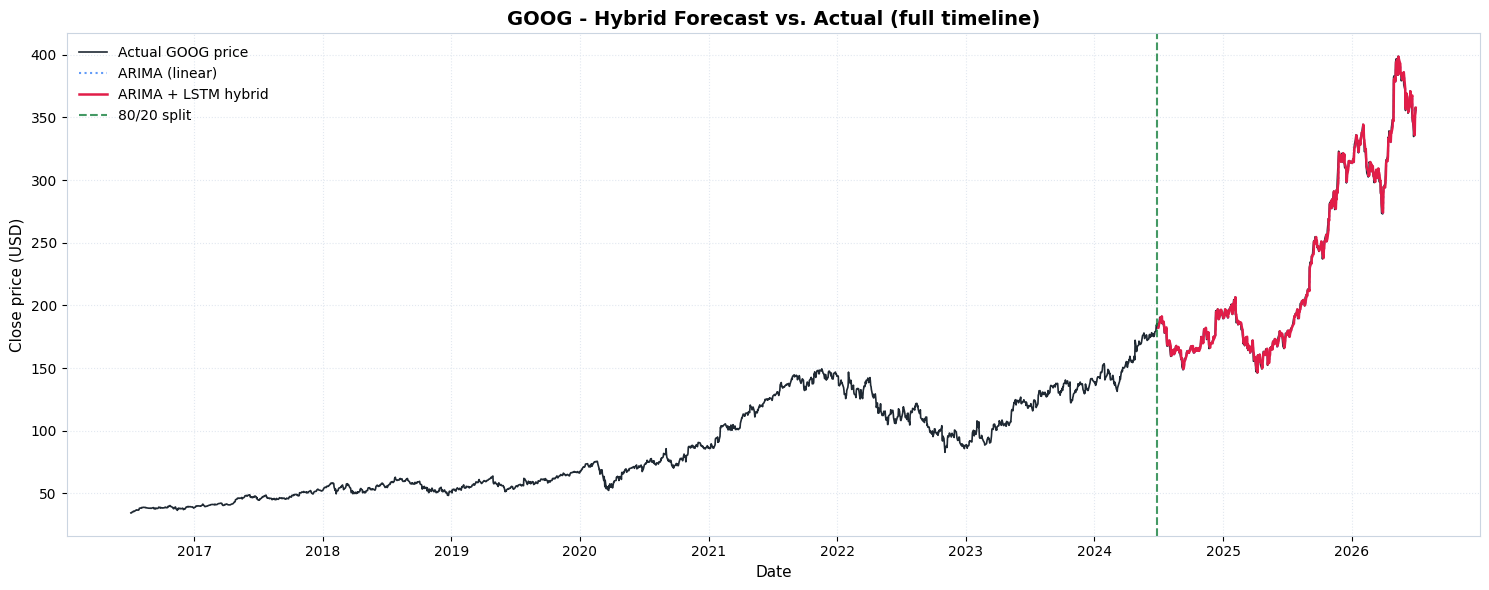

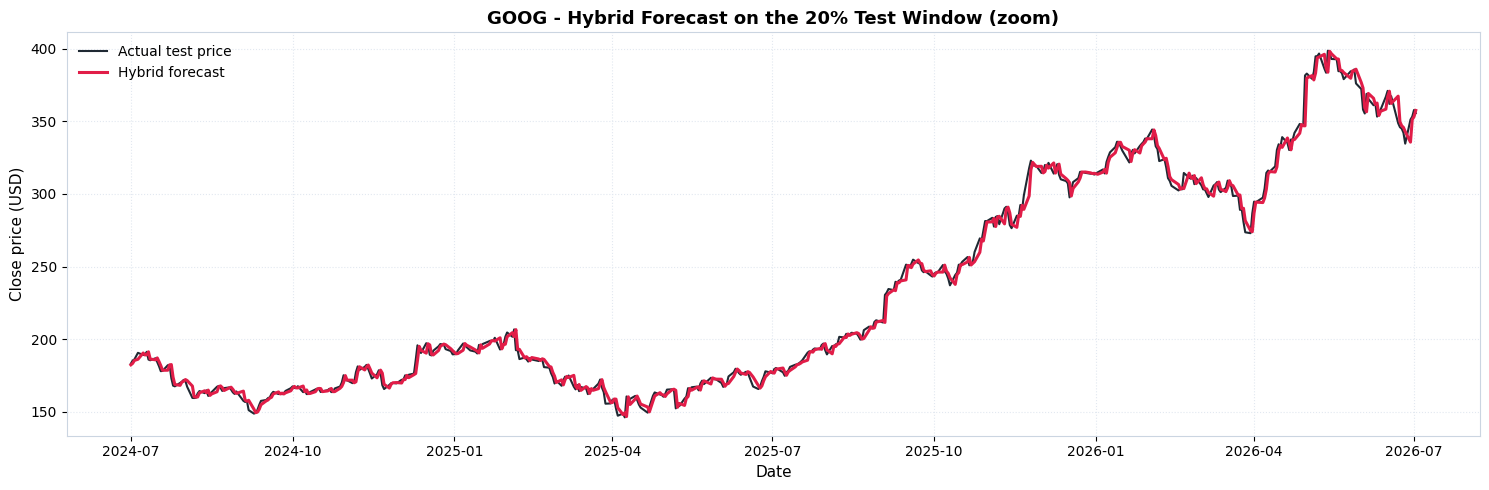

In [27]:
plt.figure(figsize=(15, 6))
plt.plot(close_prices.index, close_prices, color=PALETTE['actual'], lw=1.2, label=f'Actual {TICKER} price')
plt.plot(test_prices.index, arima_forecasts, color=PALETTE['arima'], ls=':', alpha=0.8, label='ARIMA (linear)')
plt.plot(test_prices.index, hybrid_forecasts, color=PALETTE['hybrid'], lw=1.8, label='ARIMA + LSTM hybrid')
plt.axvline(train_prices.index[-1], color=PALETTE['split'], ls='--', alpha=0.8, label='80/20 split')
plt.title(f'{TICKER} - Hybrid Forecast vs. Actual (full timeline)', fontsize=14)
plt.xlabel('Date'); plt.ylabel('Close price (USD)')
plt.legend(loc='upper left'); plt.tight_layout(); plt.show()

plt.figure(figsize=(15, 5))
plt.plot(test_prices.index, actual_test, color=PALETTE['actual'], lw=1.5, label='Actual test price')
plt.plot(test_prices.index, hybrid_forecasts, color=PALETTE['hybrid'], lw=2.2, label='Hybrid forecast')
plt.title(f'{TICKER} - Hybrid Forecast on the 20% Test Window (zoom)')
plt.xlabel('Date'); plt.ylabel('Close price (USD)')
plt.legend(loc='upper left'); plt.tight_layout(); plt.show()

====================== BACKTEST ======================
Trading days evaluated:      503
Correct directional calls:   270 days
Directional win rate:        53.68%
Buy & Hold GOOG return:        95.41%
Hybrid strategy return:       43.76%


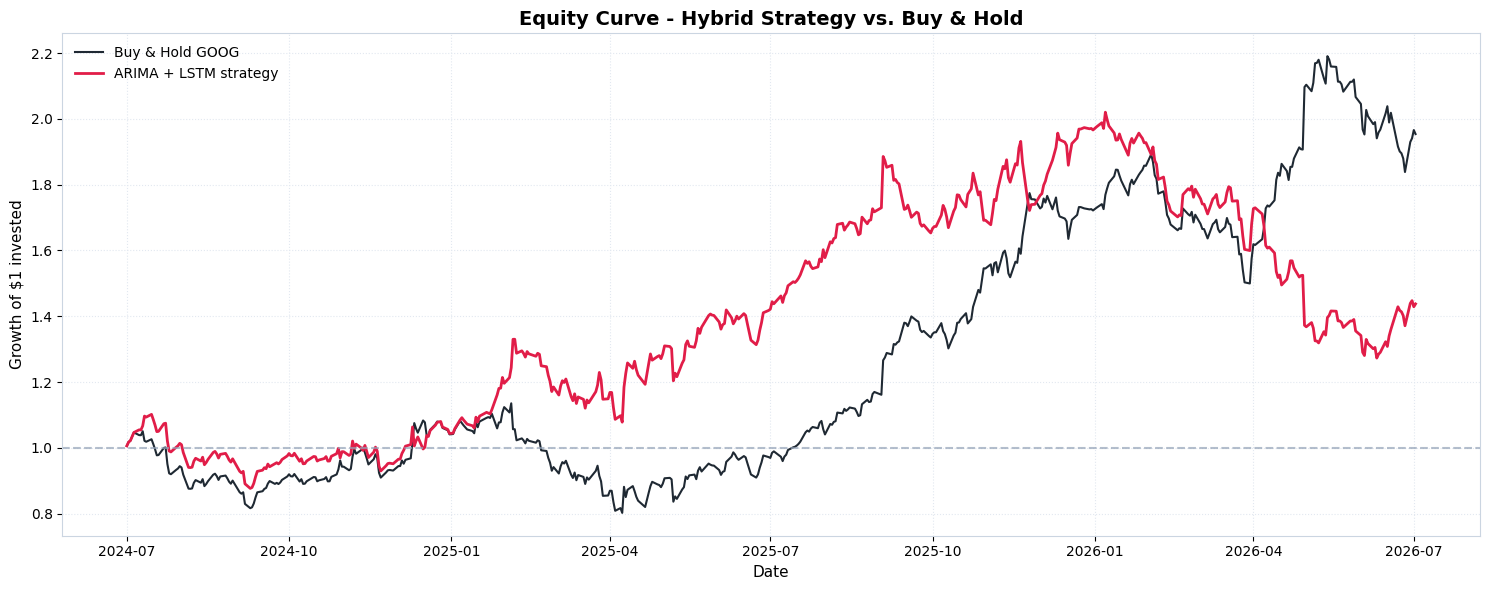

In [28]:
predicted = hybrid_forecasts

prev_prices = np.insert(actual_test[:-1], 0, train_prices.iloc[-1])

true_direction = np.where(actual_test > prev_prices, 1, 0)
pred_direction = np.where(predicted   > prev_prices, 1, 0)
correct = (true_direction == pred_direction)
win_rate = correct.mean() * 100

print('====================== BACKTEST ======================')
print(f'Trading days evaluated:      {len(actual_test)}')
print(f'Correct directional calls:   {correct.sum()} days')
print(f'Directional win rate:        {win_rate:.2f}%')
print('======================================================')

market_returns   = (actual_test - prev_prices) / prev_prices
positions        = np.where(predicted > prev_prices, 1, -1)
strategy_returns = positions * market_returns

cum_market   = np.cumprod(1 + market_returns)
cum_strategy = np.cumprod(1 + strategy_returns)

market_roi   = (cum_market[-1]   - 1) * 100
strategy_roi = (cum_strategy[-1] - 1) * 100

print(f'Buy & Hold {TICKER} return:        {market_roi:.2f}%')
print(f'Hybrid strategy return:       {strategy_roi:.2f}%')
print('======================================================')

plt.figure(figsize=(15, 6))
plt.plot(test_prices.index, cum_market,   color=PALETTE['actual'], lw=1.5, label=f'Buy & Hold {TICKER}')
plt.plot(test_prices.index, cum_strategy, color=PALETTE['hybrid'], lw=2, label='ARIMA + LSTM strategy')
plt.axhline(1.0, color='#94a3b8', ls='--', alpha=0.7)
plt.title('Equity Curve - Hybrid Strategy vs. Buy & Hold', fontsize=14)
plt.xlabel('Date'); plt.ylabel('Growth of $1 invested')
plt.legend(loc='upper left'); plt.tight_layout(); plt.show()